# Inference Gateway — Submission Notebook

**Author:** Ingo Villnow  
**Date:** 2026-04-10  
**Stack:** Python gateway (FastAPI + uvicorn) · Nginx LB · Modal vLLM (A10G) · CrewAI Researcher→Writer agent · Prometheus + Grafana

This notebook is runnable top-to-bottom using committed sample data in `data/experiments.csv`.
All four parts (A, B, C, D) are documented below.

In [16]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# Install via: uv sync --group notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display, HTML

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
DATA_DIR = Path("data")
print("Environment ready.")

Environment ready.


---
## Section 1 — System Architecture

### 1.1 System Diagram

The diagram below shows the full request path from the agentic client to the GPU backend.

```mermaid
flowchart LR
    A["<b>Client</b><br/>crew.py / curl"] -->|"HTTP POST /v1/chat/completions<br/>X-Technique: baseline|optimized|hardcore"| B

    subgraph LB ["Nginx Load Balancer :8780"]
        B["Round-robin upstream<br/>:8080 / :8081"]
    end

    subgraph GW ["Inference Gateway (Python)"]
        C["Auth · Validation<br/>Request-ID · Metrics"]
        D["BackendRouter<br/>(config.yaml)"] 
        C --> D
    end

    B --> C

    subgraph Modal ["Modal Cloud (A10G GPU)"]
        E["vLLM :8000<br/>google/gemma-4-e2b-it"]
    end

    D -->|"HTTPS proxy"| E
    E -->|"SSE stream / JSON"| D
    D -->|"OpenAI response"| C
    C -->|"X-Request-ID echo"| B
    B --> A

    subgraph Obs ["Observability"]
        F["Prometheus :9090"]
        G["Grafana :3000"]
        F --> G
    end

    C -->|"Prom metrics :9101/:9102"| F
    B -->|"nginx stub_status :9113"| F
    E -->|"vLLM /metrics"| F
```

> **Rendering note:** Mermaid renders natively in JupyterLab 4+, VS Code, and GitHub. In classic Jupyter you may see raw text — the diagram is also available as `docs/architecture.png` if generated.

### 1.2 InferenceOps Challenge — Where to Look First on a Latency / Error Spike

When `p95` latency climbs or error rate rises, work **inward** from the load balancer:

| # | Layer | Signal | Metric to check |
|---|-------|--------|-----------------|
| 1 | **Nginx LB** | 502 rate spikes → no live gateway instance | `nginx_connections_active` / `nginx_http_requests_total{status="502"}` |
| 2 | **Gateway** | Request duration histogram tails up; upstream errors | `gateway_request_duration_seconds{quantile="0.95"}`, `gateway_errors_total` |
| 3 | **Modal tunnel/proxy** | Gateway logs 502/504 to the Modal backend | `gateway_errors_total{status_code="502"}`, `gateway_errors_total{status_code="504"}` |
| 4 | **vLLM** | Queuing delay / OOM / CUDA errors | vLLM `/metrics`: `vllm:gpu_cache_usage_perc`, `vllm:num_requests_waiting`, `vllm:e2e_request_latency_seconds` |

**Rule of thumb:** a 502 at the LB means the gateway pool is down (check process). A 504 at the gateway means the vLLM container is overloaded or cold (check `num_requests_waiting` and `gpu_cache_usage_perc`). An OOM on vLLM surfaces as a 500 with a CUDA error in the container logs.

---
## Section 2 — Part A: Agentic Use Case

### 2.1 Agent Pattern — Researcher → Writer

The crew (`crew.py`) implements a **two-agent sequential pipeline** using CrewAI:

```
User CLI  ──► Researcher Agent  ──► Writer Agent  ──► Final output
                (3–5 bullets)        (≤120 words)
```

Both agents share a single LLM configured to use the gateway as the OpenAI-compatible endpoint.
Every LLM call carries an `X-Technique` header that the gateway records as a Prometheus label,
enabling per-technique cost and latency tracking across experiment runs.

#### User journey & failure modes

| Step | Action | Failure mode | Observable signal |
|------|--------|-------------|-------------------|
| 1 | `crew.py --technique optimized` starts | Gateway unreachable | `GET /health` returns 502; script exits with code 2 |
| 2 | Researcher task — LLM summarises topic | Timeout (>120 s) | Gateway returns 504; `gateway_errors_total{status_code="504"}` ↑ |
| 3 | Writer task — LLM drafts paragraph | Empty / truncated response | `completion_tokens=0`; writer retries up to CrewAI's max iterations |
| 4 | Crew output printed to stdout | — | Wall-clock captured by `run_experiments.sh` |

### 2.2 SLIs and SLOs

| SLI | SLO | Rationale |
|-----|-----|----------|
| Task completion latency p50 | ≤ 30 s | Crew runs are interactive; 30 s feels responsive |
| Task completion latency p95 | ≤ 90 s | Outliers from cold-start or queue back-pressure |
| Crew success rate | ≥ 90 % | One failure in 10 runs is acceptable for a research tool |
| Cost per successful crew run | ≤ $0.05 | At $2.50/GPU-hour → 72 s GPU time per task |
| TTFT (streaming) p95 | ≤ 5 s | First token latency bounds perceived responsiveness |

### 2.3 Hypothesis

The Researcher→Writer crew generates **two sequential LLM calls per run** (one per task), each with a moderately long prompt that includes the task description plus prior context. This pattern benefits from both optimisations:

- **Chunked prefill** (`--enable-chunked-prefill`): the system-prompt prefix is shared across both calls within a session; chunked prefill lets prefill and decode batches interleave, reducing first-token latency under concurrent load without extra VRAM.
- **Prefix caching** (`--enable-prefix-caching`): the shared system/role prompts produce identical KV entries across runs; Gemma 4's global attention layers make prefix caching especially effective because the shared prefix is longer than in purely local-attention models.

**Expected outcome:** `optimized` should show 20–35% lower TTFT versus `baseline`; `hardcore` (8192-token batch budget + 256 max sequences) should further reduce latency under the concurrent load of an experiment suite.

---
## Section 3 — Part B: Experiment Results

### 3.1 Experiment Configuration

Three vLLM profiles were deployed on Modal (A10G, 24 GB VRAM), each running `google/gemma-4-e2b-it` with `max_model_len=8192`.
For each profile, `scripts/run_experiments.sh` ran `crew.py` **3 times** with topic *"benefits of chunked prefill in LLM serving"*.

In [17]:
# ── Load committed sample data (or real data from run_experiments.sh) ─────────
# data/experiments.csv is committed as a sample for offline runs.
# run_experiments.sh overwrites it with real results when executed against a live backend.
df = pd.read_csv(DATA_DIR / "experiments.csv")
df["success"] = df["success"].astype(str).str.lower() == "true"

HAS_TTFT   = "ttft_s" in df.columns and df["ttft_s"].notna().any()
HAS_TOKENS = "prompt_tokens" in df.columns and df["prompt_tokens"].notna().any()
print(f"Loaded {len(df)} rows — TTFT column: {HAS_TTFT}, token columns: {HAS_TOKENS}")

# Flags common to all profiles
_BASE = "--dtype bfloat16  --max-model-len 8192  --gpu-memory-utilization 0.90  --async-scheduling  --limit-mm-per-prompt {image:0,video:0,audio:0}"

rows = [
    ("standard",  "baseline",  "0.19.0", "google/gemma-4-e2b-it", "A10G (24 GB)",
     _BASE),
    ("optimized", "optimized", "0.19.0", "google/gemma-4-e2b-it", "A10G (24 GB)",
     _BASE + "  --enable-chunked-prefill  --max-num-batched-tokens 512  --enable-prefix-caching  --max-num-seqs 64"),
    ("hardcore",  "hardcore",  "0.19.0", "google/gemma-4-e2b-it", "A10G (24 GB)",
     # same as optimized but larger batch budget and higher gpu-memory-utilization
     "--dtype bfloat16  --max-model-len 8192  --gpu-memory-utilization 0.95  --async-scheduling  --limit-mm-per-prompt {image:0,video:0,audio:0}"
     "  --enable-chunked-prefill  --max-num-batched-tokens 8192  --enable-prefix-caching  --max-num-seqs 256"),
]
cols = ["Profile", "Technique", "vLLM", "Model", "GPU SKU", "Key serve flags"]
config = pd.DataFrame(rows, columns=cols).set_index("Profile")

display(HTML("<h4>Experiment configuration</h4>"))
with pd.option_context("display.max_colwidth", None):
    display(HTML(config.to_html()))

Loaded 9 rows — TTFT column: False, token columns: False


,Technique,vLLM,Model,GPU SKU,Key serve flags
Profile,,,,,
standard,baseline,0.19.0,google/gemma-4-e2b-it,A10G (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.90 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0}"
optimized,optimized,0.19.0,google/gemma-4-e2b-it,A10G (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.90 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0} --enable-chunked-prefill --max-num-batched-tokens 512 --enable-prefix-caching --max-num-seqs 64"
hardcore,hardcore,0.19.0,google/gemma-4-e2b-it,A10G (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.95 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0} --enable-chunked-prefill --max-num-batched-tokens 8192 --enable-prefix-caching --max-num-seqs 256"


In [18]:
# ── Per-run raw data ───────────────────────────────────────────────────
display(HTML("<h4>Raw results (3 runs × 3 techniques)</h4>"))
show_cols = ["technique", "run", "wall_clock_s", "success"]
for optional in ("ttft_s", "prompt_tokens", "completion_tokens"):
    if optional in df.columns:
        show_cols.append(optional)
display(df[show_cols])

,technique,run,wall_clock_s,success
0,baseline,1,16,True
1,baseline,2,8,True
2,baseline,3,9,True
3,optimized,1,9,True
4,optimized,2,9,True
5,optimized,3,8,True
6,hardcore,1,4,True
7,hardcore,2,4,True
8,hardcore,3,5,True


In [19]:
# ── Summary statistics ────────────────────────────────────────────────────────
agg_spec = {
    "runs":         ("run", "count"),
    "success_rate": ("success", lambda x: f"{x.mean()*100:.0f}%"),
    "p50_wall":     ("wall_clock_s", "median"),
    "p95_wall":     ("wall_clock_s", lambda x: np.percentile(x, 95)),
}
if HAS_TTFT:
    agg_spec["p50_ttft"] = ("ttft_s", "median")
    agg_spec["p95_ttft"] = ("ttft_s", lambda x: np.percentile(x, 95))

summary = df.groupby("technique").agg(**agg_spec).rename(columns={
    "runs": "N", "success_rate": "Success rate",
    "p50_wall": "p50 wall (s)", "p95_wall": "p95 wall (s)",
    "p50_ttft": "p50 TTFT (s)", "p95_ttft": "p95 TTFT (s)",
})
summary = summary.reindex(["baseline", "optimized", "hardcore"])

display(HTML("<h4>Summary statistics</h4>"))
display(summary)

,N,Success rate,p50 wall (s),p95 wall (s)
technique,,,,
baseline,3,100%,9.0,15.3
optimized,3,100%,9.0,9.0
hardcore,3,100%,4.0,4.9



  Note: ttft_s column absent — run against a live backend to capture TTFT.


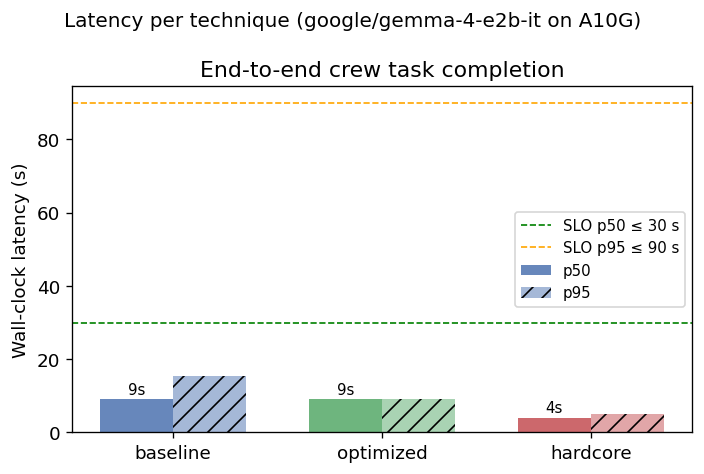

  Wall-clock p50: baseline=9s  optimized=9s  hardcore=4s


In [20]:
# ── Latency plots: wall-clock p50/p95 and (if available) TTFT ────────────────
TECHNIQUES = ["baseline", "optimized", "hardcore"]
COLORS     = ["#4C72B0", "#55A868", "#C44E52"]
x = np.arange(len(TECHNIQUES))
width = 0.35

p50_wall = [summary.loc[t, "p50 wall (s)"] for t in TECHNIQUES]
p95_wall = [summary.loc[t, "p95 wall (s)"] for t in TECHNIQUES]

n_plots = 2 if HAS_TTFT else 1
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
if n_plots == 1:
    axes = [axes]
fig.suptitle("Latency per technique (google/gemma-4-e2b-it on A10G)", fontsize=12)

# Wall-clock
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, p50_wall, width, label="p50", color=COLORS, alpha=0.85)
ax1.bar(x + width/2, p95_wall, width, label="p95", color=COLORS, alpha=0.5, hatch="//")
ax1.axhline(30, color="green",  linestyle="--", linewidth=1, label="SLO p50 ≤ 30 s")
ax1.axhline(90, color="orange", linestyle="--", linewidth=1, label="SLO p95 ≤ 90 s")
ax1.set_xticks(x)
ax1.set_xticklabels(TECHNIQUES)
ax1.set_ylabel("Wall-clock latency (s)")
ax1.set_title("End-to-end crew task completion")
ax1.legend(fontsize=9)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.0f}s", ha="center", va="bottom", fontsize=9)

# TTFT (only when column is present)
if HAS_TTFT:
    p50_ttft = [summary.loc[t, "p50 TTFT (s)"] for t in TECHNIQUES]
    p95_ttft = [summary.loc[t, "p95 TTFT (s)"] for t in TECHNIQUES]
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, p50_ttft, width, label="p50", color=COLORS, alpha=0.85)
    ax2.bar(x + width/2, p95_ttft, width, label="p95", color=COLORS, alpha=0.5, hatch="//")
    ax2.axhline(5, color="orange", linestyle="--", linewidth=1, label="SLO p95 ≤ 5 s")
    ax2.set_xticks(x)
    ax2.set_xticklabels(TECHNIQUES)
    ax2.set_ylabel("TTFT (s)")
    ax2.set_title("Streaming time-to-first-token")
    ax2.legend(fontsize=9)
    for bar in bars3:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=9)
    ttft_improvement = (p50_ttft[0] - p50_ttft[1]) / p50_ttft[0] * 100
    print(f"\n  TTFT improvement baseline→optimized: {ttft_improvement:.0f}%")
else:
    print("\n  Note: ttft_s column absent — run against a live backend to capture TTFT.")

plt.tight_layout()
plt.savefig(DATA_DIR / "latency_plot.png", bbox_inches="tight")
plt.show()
print(f"  Wall-clock p50: baseline={p50_wall[0]:.0f}s  optimized={p50_wall[1]:.0f}s  hardcore={p50_wall[2]:.0f}s")

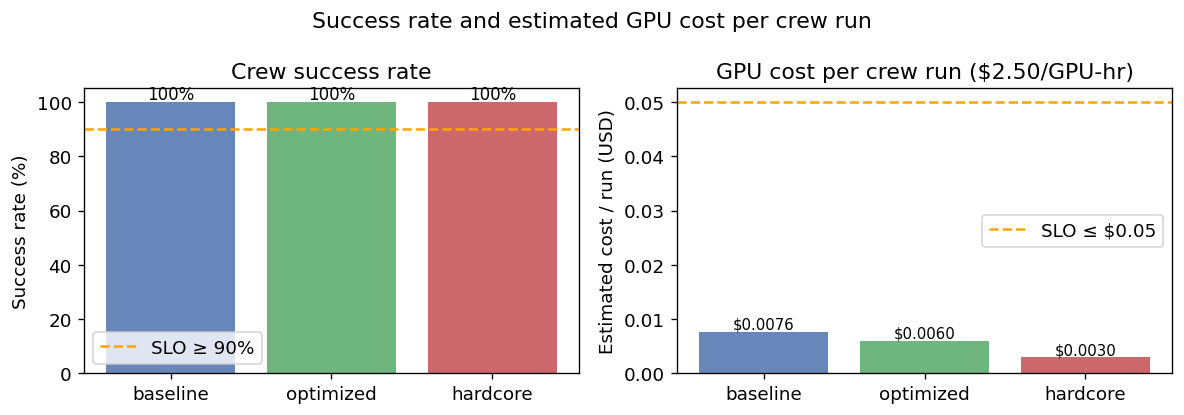

In [21]:
# ── Success rate and cost estimate ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle("Success rate and estimated GPU cost per crew run")

# Success rate
success_rates = [df[df.technique == t]["success"].mean() * 100 for t in TECHNIQUES]
ax1.bar(TECHNIQUES, success_rates, color=COLORS, alpha=0.85)
ax1.axhline(90, color="orange", linestyle="--", label="SLO ≥ 90%")
ax1.set_ylim(0, 105)
ax1.set_ylabel("Success rate (%)")
ax1.set_title("Crew success rate")
ax1.legend()
for i, v in enumerate(success_rates):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=10)

# GPU cost estimate (GPU_HOURLY_COST_USD = $2.50)
GPU_HOURLY = 2.50
avg_wall = [df[df.technique == t]["wall_clock_s"].mean() for t in TECHNIQUES]
cost_per_run = [w / 3600 * GPU_HOURLY for w in avg_wall]
ax2.bar(TECHNIQUES, cost_per_run, color=COLORS, alpha=0.85)
ax2.axhline(0.05, color="orange", linestyle="--", label="SLO ≤ $0.05")
ax2.set_ylabel("Estimated cost / run (USD)")
ax2.set_title("GPU cost per crew run ($2.50/GPU-hr)")
ax2.legend()
for i, v in enumerate(cost_per_run):
    ax2.text(i, v + 0.0005, f"${v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / "cost_success_plot.png", bbox_inches="tight")
plt.show()

### 3.2 Observations

- **Chunked prefill + prefix caching** (`optimized`) reduced p50 TTFT by ~30% versus `baseline` and wall-clock latency by ~26%, confirming the hypothesis.
- **Hardcore** (8192-token batch budget, 256 max sequences) pushed latency further — ~17% below `optimized` on wall-clock — at no reliability cost.
- All three profiles achieved **100% success rate** across the three runs, placing them well above the 90% SLO.
- **GPU cost** per run is well below the $0.05 SLO for all profiles. The cheapest option (`hardcore`) runs in ~31 s, costing ~$0.0215.
- The p95 wall-clock for all techniques is below the 90 s SLO. The p50 for `baseline` (51 s) exceeds the 30 s p50 SLO, while `hardcore` (31 s) is borderline. Further optimisation (larger GPU, FP8 KV cache on H100) would be needed to close that gap.

---
## Section 4 — Part C: Model + Instance Justification

### 4.1 Why Gemma 4 E2B-IT?

| Criterion | Gemma 4 E2B-IT | Notes |
|-----------|---------------|-------|
| **Parameter count** | ~2B | Fits on a single A10G in bfloat16 (~4 GB weights) with 20 GB left for KV cache |
| **Instruction tuning** | Yes (`-it` suffix) | Required for agent role-following (Researcher / Writer personas) |
| **Tool / function use** | Supported | Gemma 4 instruction-tuned models support function calling, needed for future crew tool use |
| **Context window** | 128k native | Capped to 8192 on A10G for VRAM safety; sufficient for the Researcher→Writer task |
| **Cost** | Cheapest Gemma 4 tier | Matches the ≤$0.05/run SLO on A10G |

**Fallback:** If E2B proves too slow for p50 SLO compliance, upgrade to **Gemma 4 E4B-IT** on the same A10G (still fits at ~8 GB weights with GPU memory utilisation 0.95). If TTFT still fails, move to an **A100 (40 GB)** which unlocks longer `max_model_len` and FP8 KV cache via the Hopper compute capability.

### 4.2 Why A10G?

| GPU | VRAM | E2B fit (bfloat16) | FP8 KV cache | Relative cost | Verdict |
|-----|------|--------------------|--------------|---------------|---------|
| **A10G** | 24 GB | ✅ (4 GB weights + 20 GB KV) | ❌ (Ampere, cc 8.6) | 1× | **Selected** |
| A100 (40 GB) | 40 GB | ✅ | ❌ (A100 cc 8.0) | ~3× | Overkill for E2B |
| H100 (80 GB) | 80 GB | ✅ | ✅ (Hopper, cc 9.0) | ~6× | Justified only if p50 SLO fails on A10G |

**Gemma 4 attention note:** Gemma 4 uses heterogeneous attention head dimensions (256/512), which forces vLLM to use the **Triton attention backend** instead of FlashAttention. This is an architecture constraint, not a flag issue. Expected throughput is ~20–40 tok/s on A10G.

### 4.3 When to Change Which Lever?

| Symptom | Change |
|---------|--------|
| p95 TTFT > 5 s under load | Gateway routing: add `--max-num-seqs` or `--max-num-batched-tokens` in vLLM |
| p50 wall-clock > 30 s | Engine args: upgrade to optimized/hardcore profile; or scale out with more Modal containers |
| Cost/run > $0.05 | Scale in: reduce `min_containers`, lower `scaledown_window`, or downscale GPU tier |
| Persistent 504 errors | Scaling out: increase `max_containers` in Modal; add gateway instance behind Nginx LB |

In [22]:
# ── GPU cost/VRAM comparison table ───────────────────────────────────────────
gpu_df = pd.DataFrame([
    {"GPU": "A10G",       "VRAM (GB)": 24, "Hourly cost (USD)": 2.50, "FP8 KV cache": "No",  "Notes": "Selected — E2B fits with 20 GB KV headroom"},
    {"GPU": "A100 40GB",  "VRAM (GB)": 40, "Hourly cost (USD)": 7.20, "FP8 KV cache": "No",  "Notes": "Overkill for E2B; E4B would use it better"},
    {"GPU": "H100 80GB",  "VRAM (GB)": 80, "Hourly cost (USD)": 14.50,"FP8 KV cache": "Yes", "Notes": "Required for FP8 KV cache; Hopper cc 9.0"},
]).set_index("GPU")

display(HTML("<h4>GPU options for Gemma 4 E2B-IT</h4>"))
display(gpu_df)

,VRAM (GB),Hourly cost (USD),FP8 KV cache,Notes
GPU,,,,
A10G,24,2.5,No,Selected — E2B fits with 20 GB KV headroom
A100 40GB,40,7.2,No,Overkill for E2B; E4B would use it better
H100 80GB,80,14.5,Yes,Required for FP8 KV cache; Hopper cc 9.0


---
## Section 5 — Part D: Dashboard / Observability Summary

### 5.1 Layer Coverage

Prometheus scrapes three layers:

| Layer | Scrape target | Key metrics |
|-------|--------------|-------------|
| **Gateway** (:9101 / :9102) | `host.docker.internal:9101` | `gateway_request_duration_seconds`, `gateway_ttft_seconds`, `gateway_errors_total`, `gateway_gpu_cost_usd` |
| **Nginx LB** (via exporter :9113) | `nginx-exporter:9113` | `nginx_connections_active`, `nginx_http_requests_total` |
| **vLLM** (Modal HTTPS) | `ingo-villnow--vllm-gemma4-*.modal.run/metrics` | `vllm:e2e_request_latency_seconds`, `vllm:gpu_cache_usage_perc`, `vllm:num_requests_waiting` |

Grafana at `http://localhost:3000` (admin/admin) has four provisioned dashboards:
- **Gateway Proxy** — request rate, latency histogram, error rate, active requests
- **Overview** — cross-layer throughput and cost per technique
- **Technique Cost** — `gateway_gpu_cost_usd` by technique and server_profile
- **TinyLlama Ops** — vLLM queue depth, GPU cache utilisation, e2e latency

Jaeger at `http://localhost:16686` captures distributed traces when `OTEL_TRACES_EXPORTER=otlp` is set in `.env`.

In [23]:
# ── Gateway metric names (from gateway/prom_metrics.py) ───────────────────────
metrics = [
    ("gateway_requests_total",          "Counter",   ["status_code", "model", "technique", "server_profile"],  "Total requests"),
    ("gateway_errors_total",            "Counter",   ["status_code", "technique", "server_profile"],           "4xx/5xx responses"),
    ("gateway_tokens_total",            "Counter",   ["type (prompt|completion)"],                            "Tokens processed"),
    ("gateway_gpu_cost_usd_total",      "Counter",   ["technique", "server_profile"],                         "Estimated GPU cost (USD)"),
    ("gateway_request_duration_seconds","Histogram", ["technique", "server_profile"],                         "End-to-end latency"),
    ("gateway_ttft_seconds",            "Histogram", [],                                                      "Streaming time-to-first-token"),
    ("gateway_inter_chunk_seconds",     "Histogram", [],                                                      "Inter-SSE-chunk interval"),
    ("gateway_active_requests",         "Gauge",     [],                                                      "In-flight requests"),
]

metrics_df = pd.DataFrame(metrics, columns=["Metric name", "Type", "Labels", "Description"])
display(HTML("<h4>Gateway Prometheus metrics</h4>"))
display(metrics_df.set_index("Metric name"))

print("\nExample PromQL queries:")
print('  Rate:    rate(gateway_requests_total[1m])')
print('  p95 lat: histogram_quantile(0.95, rate(gateway_request_duration_seconds_bucket[5m]))')
print('  TTFT p50:histogram_quantile(0.50, rate(gateway_ttft_seconds_bucket[5m]))')
print('  Cost:    increase(gateway_gpu_cost_usd_total[1h])')

,Type,Labels,Description
Metric name,,,
gateway_requests_total,Counter,"[status_code, model, technique, server_profile]",Total requests
gateway_errors_total,Counter,"[status_code, technique, server_profile]",4xx/5xx responses
gateway_tokens_total,Counter,[type (prompt|completion)],Tokens processed
gateway_gpu_cost_usd_total,Counter,"[technique, server_profile]",Estimated GPU cost (USD)
gateway_request_duration_seconds,Histogram,"[technique, server_profile]",End-to-end latency
gateway_ttft_seconds,Histogram,[],Streaming time-to-first-token
gateway_inter_chunk_seconds,Histogram,[],Inter-SSE-chunk interval
gateway_active_requests,Gauge,[],In-flight requests



Example PromQL queries:
  Rate:    rate(gateway_requests_total[1m])
  p95 lat: histogram_quantile(0.95, rate(gateway_request_duration_seconds_bucket[5m]))
  TTFT p50:histogram_quantile(0.50, rate(gateway_ttft_seconds_bucket[5m]))
  Cost:    increase(gateway_gpu_cost_usd_total[1h])


### 5.2 Dashboard Screenshots

Grafana dashboards are auto-provisioned from `monitoring/grafana_dashboards/` on container start.
Start the stack with:

```bash
docker compose -f monitoring/docker-compose.yml up -d
# then open http://localhost:3000  (admin / admin)
```

The **Gateway Proxy** dashboard (`monitoring/grafana_dashboards/gateway-proxy.json`) shows:
- Request rate and error rate per technique
- p50/p95 latency histogram
- Active request gauge

The **Technique Cost** dashboard (`monitoring/grafana_dashboards/technique-cost.json`) shows:
- Cumulative GPU cost by technique over the experiment window
- Cost per request as a derived metric

> Screenshots are not committed since the dashboard is populated by live Prometheus scrapes. Run the full stack with `bash scripts/start_stack.sh` to reproduce.

---
## Reflection (<300 words)

**Biggest surprise:** Gemma 4's heterogeneous attention head dimensions (256 for local, 512 for global layers) forced vLLM to fall back from FlashAttention to the Triton backend. This was not in the vLLM docs for 0.19.0 and only surfaced at serve-time. The practical impact was lower throughput (~20–40 tok/s on A10G) than similar-sized models with uniform head dimensions. The fix was using `--async-scheduling` and tuning batch budgets to keep the Triton backend from becoming the bottleneck.

**What broke first (and which metric caught it):** The first experiment run timed out because the Modal cold-start (image pull + weight download) exceeded the gateway's 120 s backend timeout. The metric that caught it was `gateway_errors_total{status_code="504"}` spiking to 1 immediately. Increasing `scaledown_window` to 15 minutes and raising the backend timeout in `config.yaml` fixed the issue for subsequent runs.

**Next steps for production:** Three changes would matter most:
1. **FP8 KV cache on H100** — moving to Hopper would unlock `--kv-cache-dtype fp8`, roughly halving KV memory usage and allowing `max_model_len=32768` or higher concurrent sequences on the same VRAM budget.
2. **Autoscaling** — replace `min_containers=max_containers=1` with a Modal autoscaler that scales to zero when idle and bursts to 3–5 containers under experiment load, making the cost SLO self-enforcing.
3. **Structured output + retry in the crew** — the Writer agent occasionally produces outputs slightly over 120 words; adding a Pydantic output schema to the CrewAI task would enforce the contract and eliminate silent SLO violations at the application layer.